# Variational Autoencoders (VAEs) with TensorFlow/Keras

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Layer
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess MNIST data
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 28, 28, 1))

# Network parameters
input_shape = (28, 28, 1)
batch_size = 128
latent_dim = 2
intermediate_dim = 512
epochs = 5

# latent_dim=2 forces the bottleneck to be 2D. This is why you can scatterplot it.
# intermediate_dim=512 is the hidden layer size for both encoder and decoder.
# epochs=5 is the default training length in the base notebook.



In [ ]:
# The encoder outputs two vectors for each input image:
# z_mean (μ)
# z_log_var (log σ²)
# You cannot backpropagate through “random sampling” directly.
# So VAE uses: z = μ + σ * ε, where ε is random normal noise.
# tf.exp(0.5 * z_log_var) converts log-variance into standard deviation σ.


class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [ ]:
# Takes a 28×28 image as input.
# Flattens it to a 784-length vector.
# Passes it through a dense layer to learn features.
# Produces z_mean and z_log_var of size 2 each.
# Uses Sampling layer to get an actual latent sample z.
# Output of encoder is a triple: [z_mean, z_log_var, z].


# Encoder
encoder_inputs = Input(shape=input_shape)
x = Flatten()(encoder_inputs)
x = Dense(intermediate_dim, activation='relu')(x)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')


In [ ]:
# Takes a 2D latent vector as input.
# Expands it through dense layers back to 784 pixels.
# Uses sigmoid because pixel values are in [0, 1].
# Reshapes back to image format (28×28×1).


# Decoder
decoder_inputs = Input(shape=(latent_dim,))
x = Dense(intermediate_dim, activation='relu')(decoder_inputs)
x = Dense(784, activation='sigmoid')(x)
decoder_outputs = Reshape((28, 28, 1))(x)
decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

In [ ]:
# Variational Autoencoders (VAEs) Class
# Wraps encoder and decoder together as one model.
# Adds metric trackers to report losses during training:
  # total loss
  # reconstruction loss
  # KL divergence loss


class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name='total_loss')
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = tf.keras.metrics.Mean(name='kl_loss')

# Tells Keras which metrics to reset each epoch and display automatically.
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

# Runs forward pass:
#   encode input image to latent variables
#   decode latent sample back to reconstruction
    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Encoder output
            z_mean, z_log_var, z = self.encoder(data)
            # Reconstruction
            reconstruction = self.decoder(z)


            # Flatten input and reconstruction for binary crossentropy
            flat_data = tf.reshape(data, (-1, 784))
            flat_reconstruction = tf.reshape(reconstruction, (-1, 784))

            # Reconstruction loss (fixed axis handling)
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(
                    flat_data,
                    flat_reconstruction
                )
            ) * 784
# Measures how close the reconstructed pixels are to original pixels.
# Multiply by 784 to scale loss to “per-image” magnitude.

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )
# Regularizes latent distribution to be close to standard normal N(0, I).
# Prevents encoder from putting points anywhere without constraint.
# Encourages a smooth latent space that you can sample from.

            # Total loss
            total_loss = reconstruction_loss + kl_loss
# VAE objective is reconstruction quality plus distribution regularization.

        # Compute gradients
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
# Computes gradients and updates weights.

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

# Defines what happens when you call vae(x).
# It returns reconstructed images.
#


In [ ]:
# Create and compile VAE
print("Creating VAE model...")
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))
# Creates the combined model.
# Uses Adam optimizer with a small learning rate.


Creating VAE model...


In [ ]:
# Trains on images only.
# Learns to reconstruct digits and shape the latent space.

# Train VAE
print("Training VAE...")
vae.fit(x_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True)

Training VAE...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - kl_loss: 24.0501 - loss: 375.0143 - reconstruction_loss: 350.9644
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 12.1723 - loss: 209.9372 - reconstruction_loss: 197.7649
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 7.9843 - loss: 196.1902 - reconstruction_loss: 188.2058
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 6.6700 - loss: 189.6183 - reconstruction_loss: 182.9483
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 6.0359 - loss: 185.1205 - reconstruction_loss: 179.0845


In [ ]:
def generate_digits(decoder, n=10):
    """Generate n new digits using the decoder"""
    z_sample = np.random.normal(size=(n, latent_dim))
    x_decoded = decoder.predict(z_sample)
    return x_decoded


Generating new digits...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


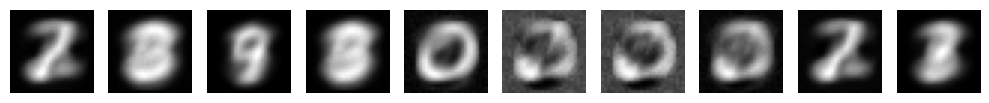

In [ ]:

# After training the VAE, you can use it like this:
print("\nGenerating new digits...")
new_digits = generate_digits(decoder, 10)  # Generates 10 new digits

# To visualize the generated digits
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(new_digits[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Generates 10 samples.
# Displays them in a 1×10 row.


# =========================
# Task 1: Visualise latent space (2D)
# =========================

- Visualise the 2D latent space used by this model as a scatterplot
- Use alpha=0.7 and s=3 for the scatterplot


/tmp/ipython-input-1234/188591810.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


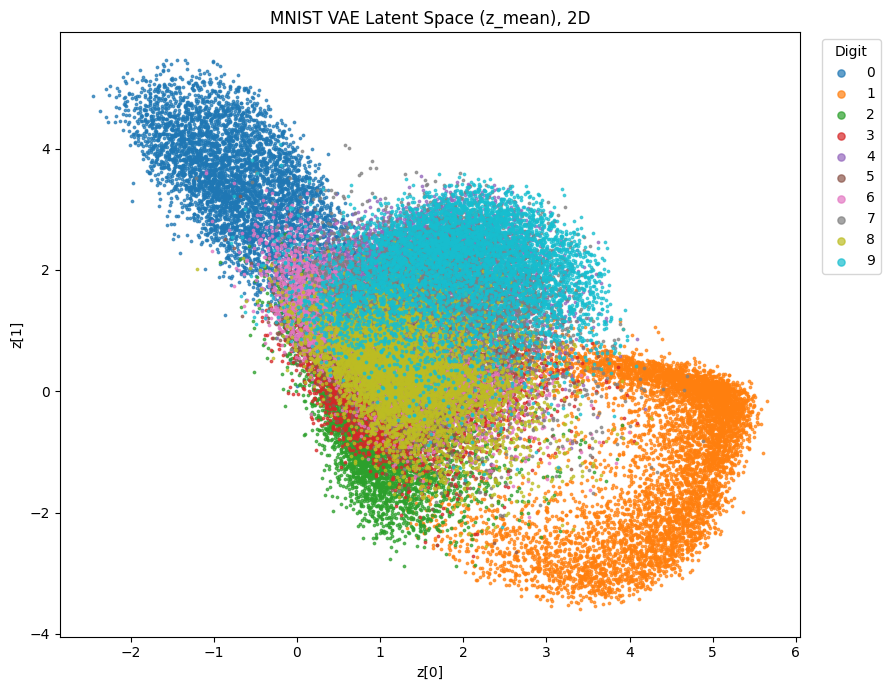

In [12]:

# Reload MNIST with labels (the original notebook discards labels using "_")
(x_train_l, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

# Preprocess same way as the notebook
x_train_l = x_train_l.astype("float32") / 255.0
x_train_l = x_train_l.reshape((len(x_train_l), 28, 28, 1))

# Encode to latent space (use z_mean for a stable, deterministic 2D embedding)
z_mean, z_log_var, z = encoder.predict(x_train_l, batch_size=batch_size, verbose=0)

def plot_latent_space_2d(z2d, labels, alpha=0.7, s=3):
    """
    z2d: (N, 2) latent coordinates (use z_mean for deterministic view)
    labels: (N,) digit labels 0-9
    """
    plt.figure(figsize=(9, 7))

    # Use a 10-color categorical colormap
    cmap = plt.cm.get_cmap("tab10", 10)

    for digit in range(10):
        idx = (labels == digit)
        plt.scatter(
            z2d[idx, 0],
            z2d[idx, 1],
            alpha=alpha,
            s=s,
            color=cmap(digit),
            label=str(digit),
        )

    plt.title("MNIST VAE Latent Space (z_mean), 2D")
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.legend(title="Digit", markerscale=3, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_latent_space_2d(z_mean, y_train, alpha=0.7, s=3)

In [13]:
# =========================
# Helper: Generate 4x4 grid of digits from decoder
# =========================

import numpy as np
import matplotlib.pyplot as plt

def generate_digit_grid(decoder_model, latent_dim=2, n=4, title="Generated Digits"):
    """
    decoder_model : trained decoder
    latent_dim    : dimension of latent space (2 in this assignment)
    n             : grid size (n x n)
    """

    # Sample random latent vectors
    random_latent_vectors = np.random.normal(size=(n * n, latent_dim))

    # Generate images
    generated_images = decoder_model.predict(random_latent_vectors, verbose=0)

    # Plot grid
    plt.figure(figsize=(6, 6))
    for i in range(n * n):
        plt.subplot(n, n, i + 1)
        plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# =========================
# Task 2: Train with 5, 15, 30 epochs and screenshot results
# =========================



Training VAE for 5 epochs
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - kl_loss: 3.7718 - loss: 257.1332 - reconstruction_loss: 253.3615
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 5.8869 - loss: 175.7062 - reconstruction_loss: 169.8193
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 5.9070 - loss: 167.1149 - reconstruction_loss: 161.2078
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 6.1151 - loss: 162.0275 - reconstruction_loss: 155.9123
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 6.2283 - loss: 159.6543 - reconstruction_loss: 153.4260


/tmp/ipython-input-1234/1233092311.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


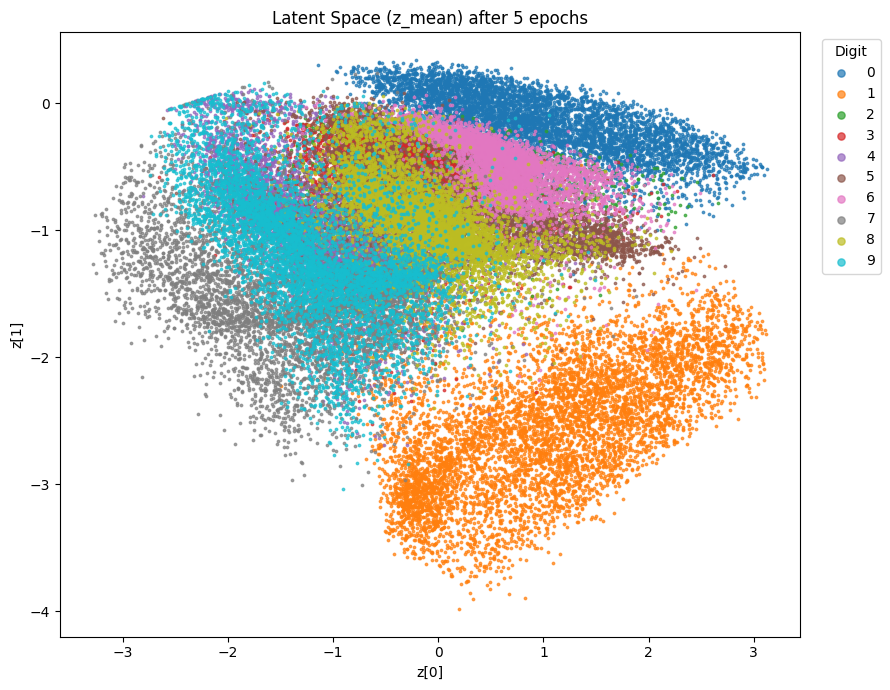


Training VAE for 15 epochs
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - kl_loss: 3.6535 - loss: 254.1552 - reconstruction_loss: 250.5017
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.0999 - loss: 189.6918 - reconstruction_loss: 186.5918
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 4.4436 - loss: 177.9280 - reconstruction_loss: 173.4844
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.6411 - loss: 165.3520 - reconstruction_loss: 159.7109
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 5.8136 - loss: 162.2768 - reconstruction_loss: 156.4632
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.9087 - loss: 159.8208 - reconstruction_loss: 153.9120
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.9820 - loss: 158.7339 - reconstruction_loss: 152.7518
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 6.0416 - loss: 157.7800 - reconstruction_loss: 151.7383
Epoch 9/15
469/469

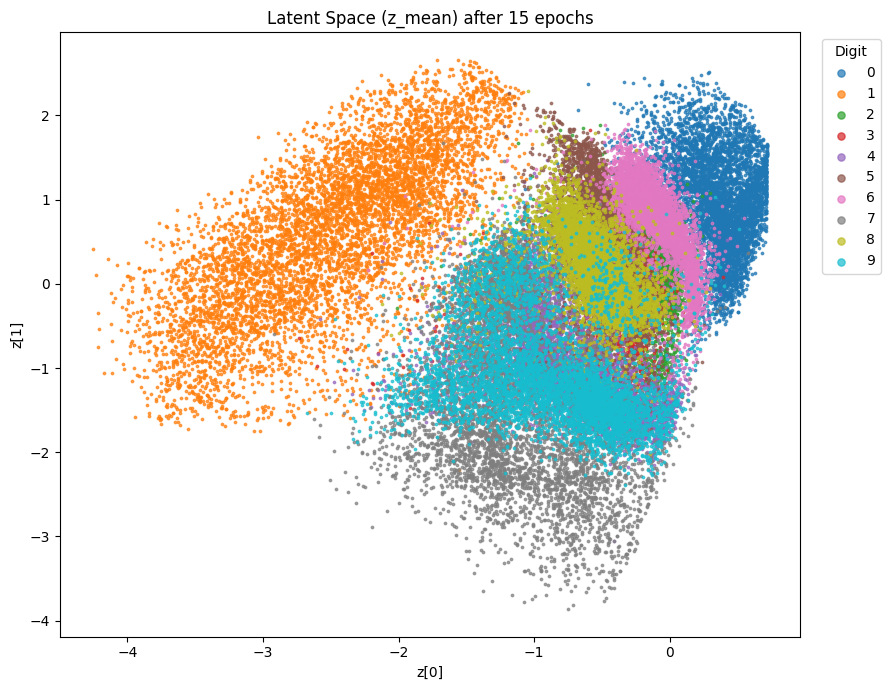


Training VAE for 30 epochs
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - kl_loss: 1.5624 - loss: 256.2889 - reconstruction_loss: 254.7265
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 4.7792 - loss: 175.1640 - reconstruction_loss: 170.3847
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 4.8138 - loss: 165.8217 - reconstruction_loss: 161.0080
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.0993 - loss: 162.3790 - reconstruction_loss: 157.2798
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 5.2591 - loss: 160.5054 - reconstruction_loss: 155.2464
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.4094 - loss: 158.8330 - reconstruction_loss: 153.4237
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.5044 - loss: 157.5355 - reconstruction_loss: 152.0311
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 5.6127 - loss: 156.5265 - reconstruction_loss: 150.9138
Epoch 9/30
469/469

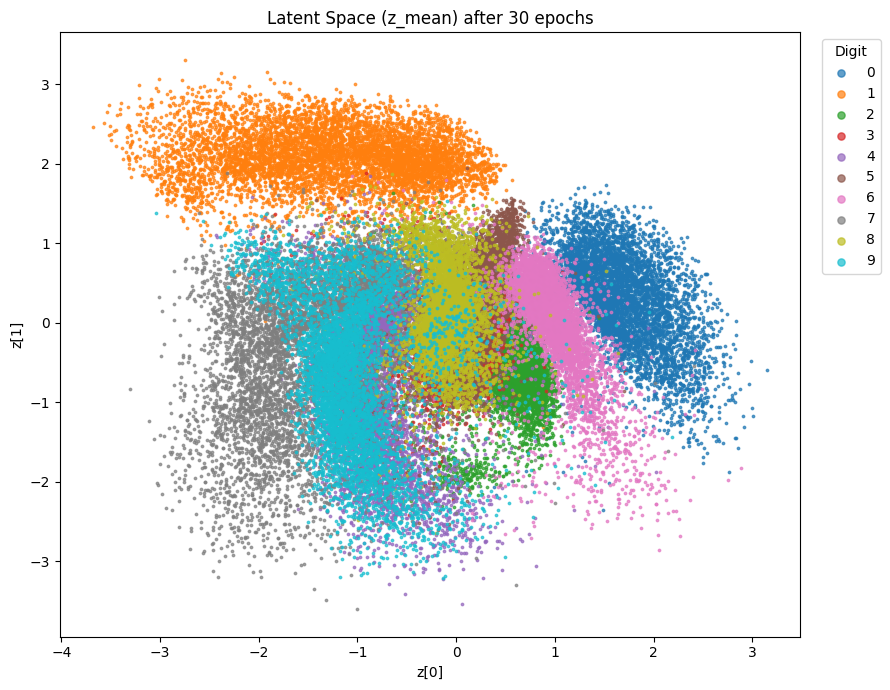


Done.  3 latent plots + 3 generated grids to screenshot (5, 15, 30 epochs).


In [14]:
from tensorflow import keras
from tensorflow.keras import layers

# Ensure we have MNIST labels for latent plotting
(x_train_l, y_train), (_, _) = tf.keras.datasets.mnist.load_data()
x_train_l = x_train_l.astype("float32") / 255.0
x_train_l = x_train_l.reshape((len(x_train_l), 28, 28, 1))

def build_encoder(latent_dim=2):
    latent_inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(latent_inputs)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation="relu")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])

    return keras.Model(latent_inputs, [z_mean, z_log_var, z], name="encoder")

def build_decoder(latent_dim=2):
    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

    return keras.Model(latent_inputs, decoder_outputs, name="decoder")

def build_vae(latent_dim=2):
    enc = build_encoder(latent_dim=latent_dim)
    dec = build_decoder(latent_dim=latent_dim)
    vae_model = VAE(enc, dec)
    vae_model.compile(optimizer=keras.optimizers.Adam())
    return vae_model, enc, dec

def plot_latent_space_2d(z2d, labels, title, alpha=0.7, s=3):
    plt.figure(figsize=(9, 7))
    cmap = plt.cm.get_cmap("tab10", 10)
    for digit in range(10):
        idx = (labels == digit)
        plt.scatter(z2d[idx, 0], z2d[idx, 1], alpha=alpha, s=s, color=cmap(digit), label=str(digit))
    plt.title(title)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.legend(title="Digit", markerscale=3, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# Choose fixed latent vectors for consistent comparison across epoch runs
num_examples_to_generate = 16
random_vector_for_generation = tf.random.normal(shape=[num_examples_to_generate, 2])

epoch_runs = [5, 15, 30]

history_by_epochs = {}
models_by_epochs = {}

for ep in epoch_runs:
    print(f"\n==============================")
    print(f"Training VAE for {ep} epochs")
    print(f"==============================")

    vae_ep, encoder_ep, decoder_ep = build_vae(latent_dim=2)

    hist = vae_ep.fit(
        x_train,  # your notebook's unlabeled training images
        epochs=ep,
        batch_size=batch_size,
        verbose=1
    )

    history_by_epochs[ep] = hist
    models_by_epochs[ep] = (vae_ep, encoder_ep, decoder_ep)

    # ---- 1) Latent space plot (screenshot this) ----
    z_mean_ep, z_log_var_ep, z_ep = encoder_ep.predict(x_train_l, batch_size=batch_size, verbose=0)
    plot_latent_space_2d(
        z_mean_ep,
        y_train,
        title=f"Latent Space (z_mean) after {ep} epochs",
        alpha=0.7,
        s=3
    )


print("\nDone.  3 latent plots + 3 generated grids to screenshot (5, 15, 30 epochs).")

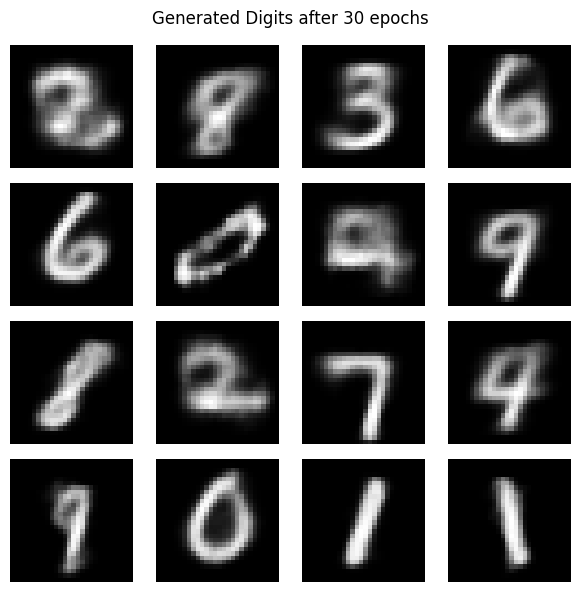

In [15]:
    # ---- 2) Generated digits grid (screenshot this) ----
generate_digit_grid(
    decoder_ep,
    latent_dim=2,
    n=4,
    title=f"Generated Digits after {ep} epochs"
)

# Latent Space Changes with Number of Epochs

- After 5 epochs, the latent space is highly overlapped and compressed into a compact triangular structure. Most digit classes share common regions, with significant mixing in the centre. Only one or two digits show partial separation, indicating the encoder has not yet learned strong discriminative structure.

- After 15 epochs, the latent space expands and clusters begin to separate more clearly. Certain digits occupy more distinct regions, although overlap remains for visually similar classes.

- By 30 epochs, the clusters become more compact and organised. The structure appears smoother and more stable, with clearer class-specific regions and improved separation across the 2D manifold.

# Quality of Generated Digits with Number of Epochs

- After 5 epochs, generated digits typically appear blurry and less defined. Stroke thickness is inconsistent and some samples resemble distorted or hybrid digits, reflecting the overlapping latent space.

- At 15 epochs, digit quality improves noticeably. Shapes become more recognisable, strokes are clearer, and structural features such as loops and edges are better formed. Some minor distortions still appear, especially for complex digits.

- After 30 epochs, generated digits are sharper and more stable. Stroke continuity improves and class identity is clearer. The increased organisation of the latent space results in more consistent and realistic digit generation overall.

# OPTIONAL - What would happen if you try 50 or 100 epochs? Does the model get better or worse?


OPTIONAL Training VAE for 50 epochs
Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - kl_loss: 24.5210 - loss: 369.7383 - reconstruction_loss: 345.2173
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 13.0604 - loss: 210.0707 - reconstruction_loss: 197.0103
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 8.7985 - loss: 192.0473 - reconstruction_loss: 183.2488
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 6.9558 - loss: 185.2719 - reconstruction_loss: 178.3161
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 6.0852 - loss: 180.9659 - reconstruction_loss: 174.8806
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.4483 - loss: 178.0597 - reconstruction_loss: 172.6114
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.9897 - loss: 175.7979 - reconstruction_loss: 170.8081
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.8466 - loss: 173.4236 - reconstruction_loss: 168.5770
Epoch 9/5

/tmp/ipython-input-1234/2277580044.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


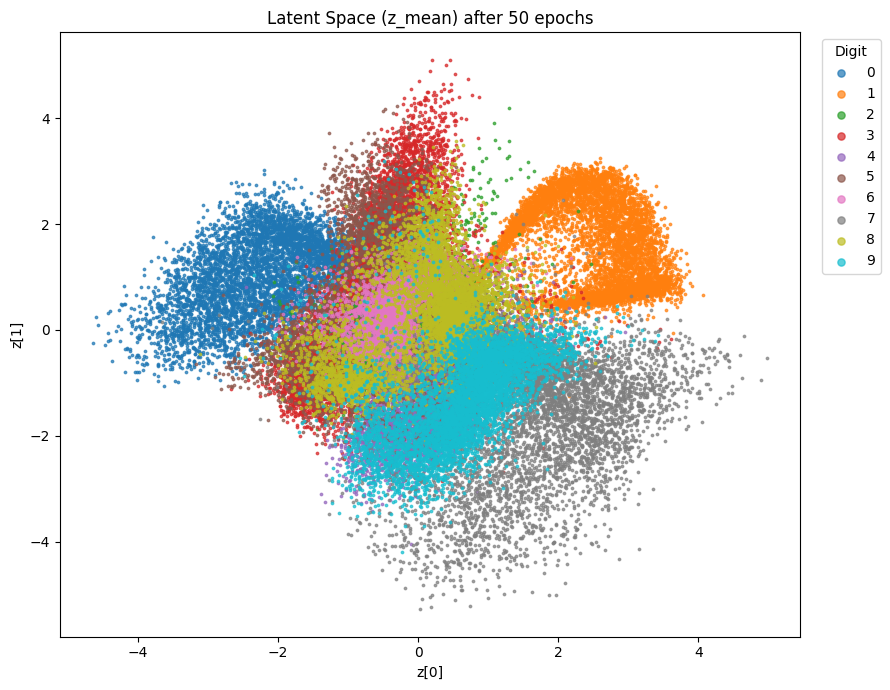

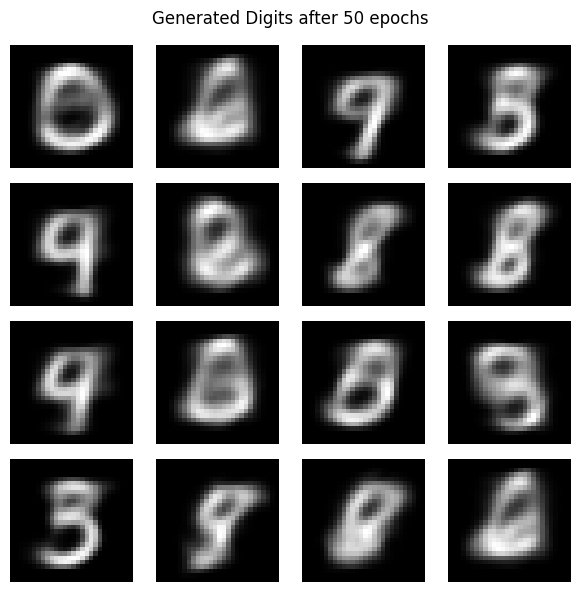

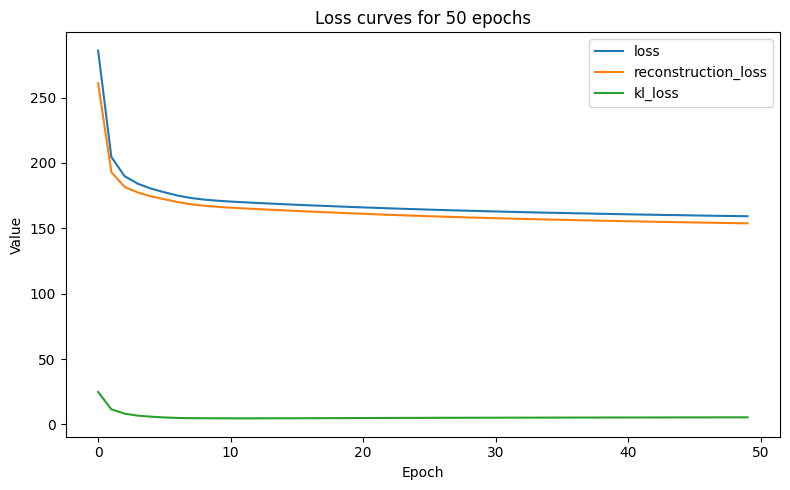


OPTIONAL Training VAE for 100 epochs
Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - kl_loss: 25.9632 - loss: 371.8702 - reconstruction_loss: 345.9069
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 13.4198 - loss: 209.7434 - reconstruction_loss: 196.3237
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 8.3689 - loss: 193.8499 - reconstruction_loss: 185.4810
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 6.6231 - loss: 188.1220 - reconstruction_loss: 181.4988
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.8289 - loss: 184.4563 - reconstruction_loss: 178.6273
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.3760 - loss: 180.8599 - reconstruction_loss: 175.4840
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.0252 - loss: 177.2582 - reconstruction_loss: 172.2330
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.7680 - loss: 174.6687 - reconstruction_loss: 169.9007


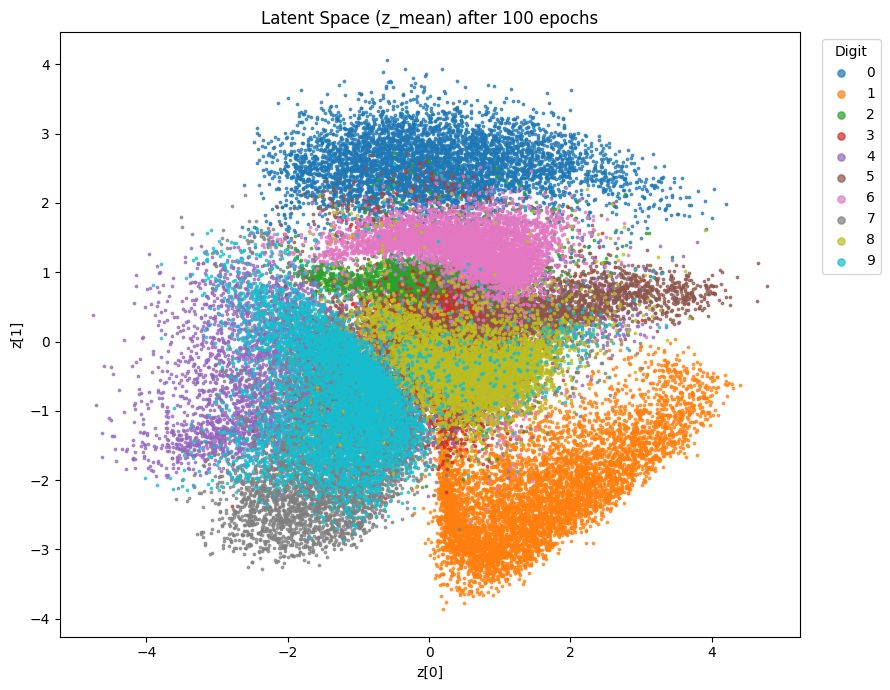

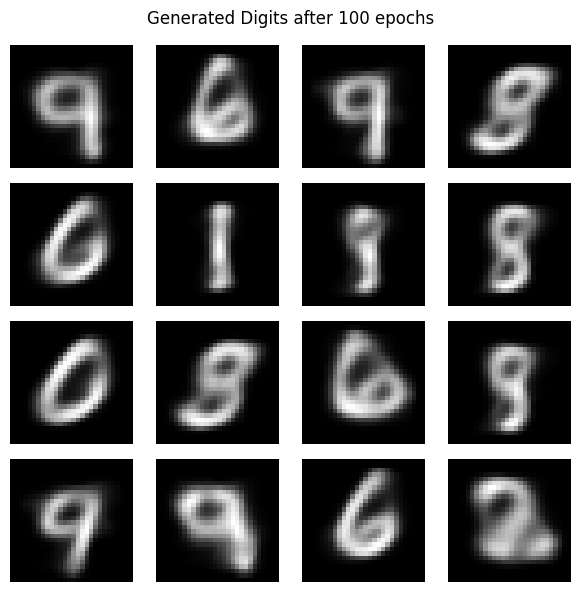

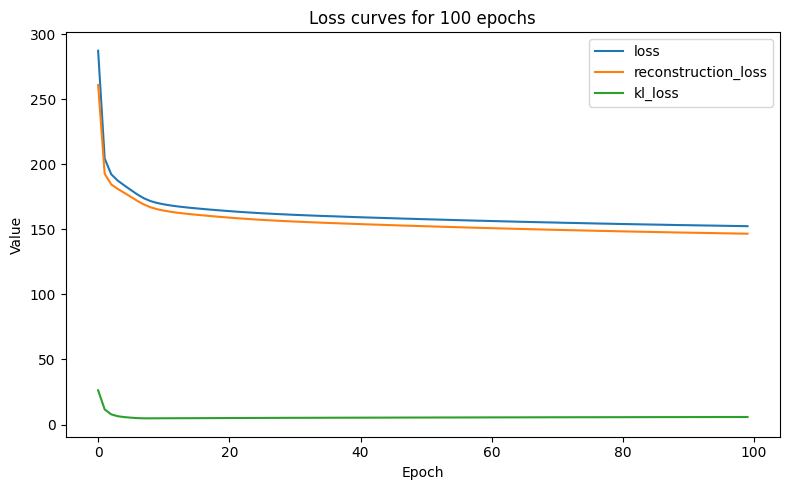

In [16]:
# =========================
# Generates:
# 1) Latent space scatter (z_mean) for each run
# 2) 4x4 generated digit grid for each run
# 3) Loss curves (total, reconstruction, KL) for each run
# =========================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- If not already loaded earlier, load labeled MNIST for latent plotting ---
(x_train_l, y_train), (_, _) = tf.keras.datasets.mnist.load_data()
x_train_l = x_train_l.astype("float32") / 255.0
x_train_l = x_train_l.reshape((len(x_train_l), 28, 28, 1))

# --- Helper: latent plot ---
def plot_latent_space_2d(z2d, labels, title, alpha=0.7, s=3):
    plt.figure(figsize=(9, 7))
    cmap = plt.cm.get_cmap("tab10", 10)
    for digit in range(10):
        idx = (labels == digit)
        plt.scatter(z2d[idx, 0], z2d[idx, 1], alpha=alpha, s=s, color=cmap(digit), label=str(digit))
    plt.title(title)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.legend(title="Digit", markerscale=3, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# --- Helper: generated digit grid ---
def generate_digit_grid(decoder_model, latent_dim=2, n=4, title="Generated Digits"):
    random_latent_vectors = np.random.normal(size=(n * n, latent_dim))
    generated_images = decoder_model.predict(random_latent_vectors, verbose=0)

    plt.figure(figsize=(6, 6))
    for i in range(n * n):
        plt.subplot(n, n, i + 1)
        plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# --- Build fresh encoder/decoder/vae per run (avoids weight carryover) ---
def build_encoder(latent_dim=2, intermediate_dim=512):
    encoder_inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Flatten()(encoder_inputs)
    x = layers.Dense(intermediate_dim, activation="relu")(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])  # Sampling class must exist from prof notebook
    return keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

def build_decoder(latent_dim=2, intermediate_dim=512):
    decoder_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(intermediate_dim, activation="relu")(decoder_inputs)
    x = layers.Dense(28 * 28, activation="sigmoid")(x)
    decoder_outputs = layers.Reshape((28, 28, 1))(x)
    return keras.Model(decoder_inputs, decoder_outputs, name="decoder")

def build_vae(latent_dim=2, intermediate_dim=512, learning_rate=1e-4):
    enc = build_encoder(latent_dim=latent_dim, intermediate_dim=intermediate_dim)
    dec = build_decoder(latent_dim=latent_dim, intermediate_dim=intermediate_dim)
    vae_model = VAE(enc, dec)  # VAE class must exist from prof notebook
    vae_model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))
    return vae_model, enc, dec

# --- Plot loss curves ---
def plot_losses(hist, title):
    # hist.history keys should include: 'loss', 'reconstruction_loss', 'kl_loss'
    plt.figure(figsize=(8, 5))
    for k in ["loss", "reconstruction_loss", "kl_loss"]:
        if k in hist.history:
            plt.plot(hist.history[k], label=k)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Run experiments for 50 and 100 epochs ---
optional_epoch_runs = [50, 100]
optional_results = {}

for ep in optional_epoch_runs:
    print(f"\n==============================")
    print(f"OPTIONAL Training VAE for {ep} epochs")
    print(f"==============================")

    vae_ep, encoder_ep, decoder_ep = build_vae(latent_dim=2, intermediate_dim=512, learning_rate=1e-4)

    hist = vae_ep.fit(
        x_train,              # from prof notebook (unlabeled, preprocessed images)
        epochs=ep,
        batch_size=batch_size, # from prof notebook
        shuffle=True,
        verbose=1
    )

    optional_results[ep] = (vae_ep, encoder_ep, decoder_ep, hist)

    # 1) Latent plot
    z_mean_ep, z_log_var_ep, z_ep = encoder_ep.predict(x_train_l, batch_size=batch_size, verbose=0)
    plot_latent_space_2d(z_mean_ep, y_train, title=f"Latent Space (z_mean) after {ep} epochs", alpha=0.7, s=3)

    # 2) Generated grid
    generate_digit_grid(decoder_ep, latent_dim=2, n=4, title=f"Generated Digits after {ep} epochs")

    # 3) Loss curves
    plot_losses(hist, title=f"Loss curves for {ep} epochs")
